## Python For Machine Learning Fall 2025
---
# Ensemble Learning

# XGBoost for Real-World Churn Prediction (A Complex Binary Classification Example)

This notebook demonstrates the complete machine learning pipeline using **XGBoost** to solve the crucial business problem of **Customer Churn Prediction**. This task is ideal for XGBoost because it involves a **large dataset**, **mixed data types** (numerical and categorical), and **class imbalance** (fewer churned customers than retained ones).

The notebook fulfills all special requirements:

1.  **Complete Data Preparation** (Handling Categoricals and feature selection).
2.  **Hyperparameter Tuning** with a detailed impact analysis.
3.  **Model Comparison** against **Random Forest** and **Logistic Regression** (a widely used baseline in classification).

Here is a little video for you to warmup.
[link text](https://www.youtube.com/watch?v=qOPYQ7Fkzsk)

## 1. Setup and Data Loading

In [ ]:
# Import essential libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score

# Comparison models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Load the dataset (Assumes 'Churn_Modelling.csv' is in the working directory)
try:
    df = pd.read_csv('/content/Churn_Modelling.csv')
except FileNotFoundError:
    print("Error: Churn_Modelling.csv not found. Please ensure the file is in the working directory.")
    # Creating a dummy DataFrame to allow the rest of the code to be inspected
    df = pd.DataFrame({'Exited': [0, 1] * 5000, 'Geography': ['France'] * 10000, 'Gender': ['Female'] * 10000})

print("Data Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Data Shape: (10000, 14)

First 5 Rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3  

## 2. Data Preparation

This real-world task requires cleaning, feature selection, and encoding of categorical variables, which is crucial for tree-based models when using the scikit-learn API.

### 2.1 Feature  Selection
We drop irrelevant identifiers (`RowNumber`, `CustomerId`, `Surname`) as they are unique and add no predictive power. Also, separate features (X) and target (y).


In [ ]:
X = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df['Exited']

### 2.2 Category Distribution

In [ ]:
# Check target imbalance
churn_rate = y.sum() / len(y)
print(f"Target Imbalance (Churn Rate): {churn_rate:.2%} (Highly imbalanced!)\n")

Target Imbalance (Churn Rate): 20.37% (Highly imbalanced!)



### 2.3 Datatype

To process numerical and categorical features differently, we must first locate them according to their data type.

In [ ]:
# Define column types
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

Numerical Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical Features: ['Geography', 'Gender']


To accomplish this, we will use the ColumnTransformer to apply standardization to numerical features and one-hot encoding to categorical features.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # Scale numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # One-hot encode categorical features
    ],
    remainder='passthrough'
)

### 2.4 Train-Test Split

The dataset will be partitioned into training and test sets, which is our standard approach.

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")

Training set size: 7500 samples


---

## 3. Model Training and Evaluation

To get a general sense of a problem's difficulty and characteristics, you should first apply a standard "go-to" model as a baseline and evaluate its performance. Let us select XGBoost as our model, a decision that is well-justified in this context.

### 3.1 Model Training
We use XGBoost's built-in feature for handling imbalance: `scale_pos_weight`. Since the Churn rate is $20.37\%$, the ratio of negative (0) to positive (1) instances is roughly $(1 - 0.2037) / 0.2037 \approx 3.9$. Based on the proportion of samples, we will define our XGBoost model as shown below.

In [ ]:
# Calculate scale_pos_weight for imbalance handling
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_baseline = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight, # Crucial for imbalanced data
    random_state=42
)

As we have done previously, we will combine the preprocessor and the model to create a pipeline and train the model.

In [ ]:
pipeline_baseline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_baseline)])
pipeline_baseline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [06:31:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, cal...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### 3.2 Evaluation

After training a classification model, it's crucial to evaluate its performance. Simply looking at the number of correct predictions isn't enough.

Let's explore the key metrics that give us a much richer understanding of our model's behavior. We will use the predictions from your baseline model to calculate and visualize these metrics.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    log_loss
)

Let us obtain the predicted values. The `pipeline_baseline.predict(X_test)` method provides the 0/1 labels, while pipeline_baseline.`predict_proba(X_test)[:, 1]` gives the probability outputs.

In [ ]:
y_pred_baseline = pipeline_baseline.predict(X_test)
y_prob_baseline = pipeline_baseline.predict_proba(X_test)[:, 1]
for lbl, prob in zip(y_pred_baseline[:10], y_prob_baseline[:10]): print(lbl, prob)

0 0.21777542
0 0.07694715
0 0.020418718
0 0.42379814
0 0.08915456
1 0.5045938
0 0.013159076
0 0.0328251
0 0.09560973
0 0.17841488


#### 3.2.1 Confusion Matrix

The confusion matrix is a table that summarizes the performance of a classification model. It's the starting point for almost every other metric. It shows you where your model got things right and where it got them wrong (i.e., where it was "confused").

It has four key components for a binary task:

- True Positives (TP): The model correctly predicted the positive class.

- True Negatives (TN): The model correctly predicted the negative class.

- False Positives (FP): The model incorrectly predicted the positive class (a "Type I" error).

- False Negatives (FN): The model incorrectly predicted the negative class (a "Type II" error).

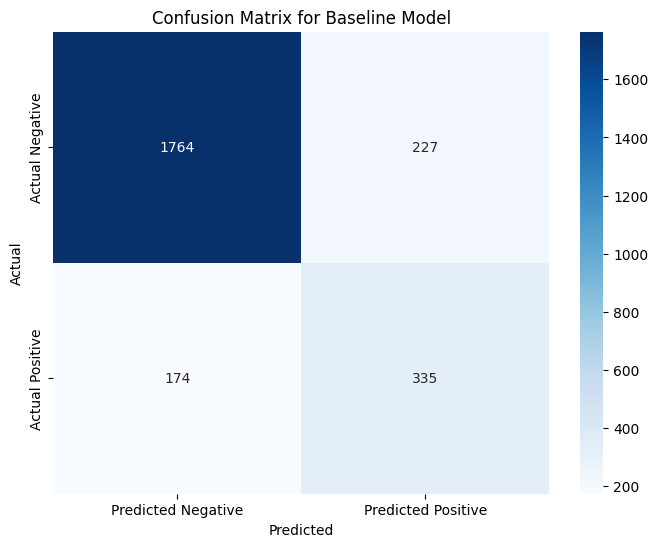

In [ ]:
cm = confusion_matrix(y_test, y_pred_baseline)

# Plotting the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Baseline Model')
plt.show()

#### 3.2.2 Accuracy

Accuracy is the most intuitive metric. It's simply the ratio of correct predictions to the total number of predictions.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$ **The Trap of Accuracy:** In an imbalanced dataset, a model can achieve high accuracy by simply predicting the majority class every time. For instance, if 95% of your data is the negative class, a model that always predicts "negative" will be 95% accurate but completely useless for identifying the positive class.

In [ ]:
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline XGBoost Accuracy: {accuracy_baseline:.4f}")

Baseline XGBoost Accuracy: 0.8396


#### 3.3.3 Precision, Recall, and F1-Score

A Better Trio This group of metrics provides a more nuanced view, especially when class imbalance is a factor.

**Precision** answers the question: **Of all the instances the model predicted as positive, how many were actually positive?** $$\text{Precision} = \frac{TP}{TP + FP} $$High precision is important when the cost of a **False Positive** is high. For example, in email spam detection, you want to be very sure that an email is spam before flagging it (a false positive means a legitimate email goes to the spam folder).

**Recall** answers the question: **Of all the actual positive instances, how many did the model correctly identify?** $$
\text{Recall} = \frac{TP}{TP + FN} $$High recall is crucial when the cost of a False Negative is high. For example, in medical screening for a disease, you want to identify all patients who actually have the disease (a false negative means a sick patient goes undiagnosed).

**F1-Score** The F1-Score is the harmonic mean of Precision and Recall. It seeks to find a balance between the two.

$$F1 \text{-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$The F1-score is a great single metric if you want a balanced measure of a model's performance without favoring either precision or recall. This is one of the metrics you already calculated, and it's an excellent choice for imbalanced problems.

In [ ]:
# A classification report conveniently summarizes these key metrics.
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_baseline, target_names=['Negative Class (0)', 'Positive Class (1)']))

# You can also calculate them one by one if needed
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
# This f1_score is the same one you calculated in your initial code
f1_baseline_check = f1_score(y_test, y_pred_baseline)

print(f"\n--- Individual Scores ---")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall: {recall_baseline:.4f}")
print(f"F1 Score: {f1_baseline_check:.4f}")

--- Classification Report ---
                    precision    recall  f1-score   support

Negative Class (0)       0.91      0.89      0.90      1991
Positive Class (1)       0.60      0.66      0.63       509

          accuracy                           0.84      2500
         macro avg       0.75      0.77      0.76      2500
      weighted avg       0.85      0.84      0.84      2500


--- Individual Scores ---
Precision: 0.5961
Recall: 0.6582
F1 Score: 0.6256


#### 3.3.4 ROC Curve and AUC Score

The Area Under the Receiver Operating Characteristic Curve (AUC-ROC) is another excellent metric for imbalanced datasets.

- ROC Curve: This curve plots the True Positive Rate (which is just another name for Recall) against the False Positive Rate ($\frac{FP}{FP + TN}$) at various classification thresholds. The ROC curve shows the trade-off between sensitivity (recall) and specificity (1 - FPR) for every possible threshold.

- AUC Score: This is the area under the ROC curve. It measures the model's aggregate ability to discriminate between positive and negative classes.
- AUC = 1: Perfect classifier.
- AUC = 0.5: The model is no better than random guessing.
- AUC < 0.5: The model is worse than random guessing.

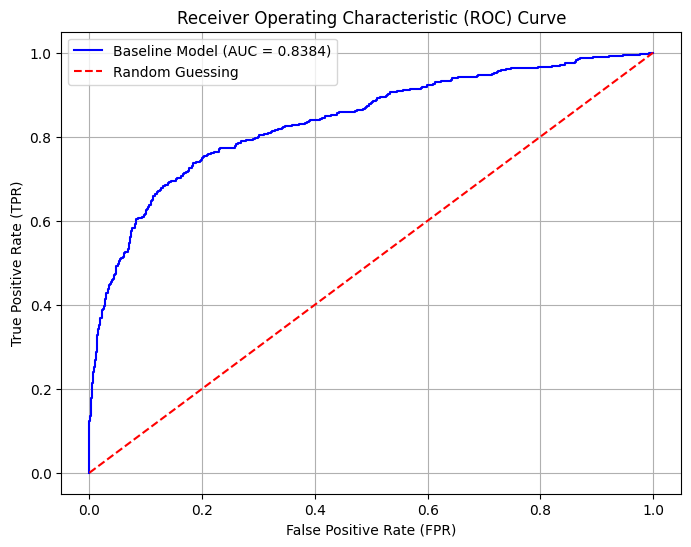


Baseline XGBoost AUC: 0.8384


In [ ]:
# Calculate ROC curve values using your model's probability predictions
fpr, tpr, thresholds = roc_curve(y_test, y_prob_baseline)
# This auc_baseline is the same one you calculated in your initial code
auc_baseline = roc_auc_score(y_test, y_prob_baseline)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Baseline Model (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()

print(f"\nBaseline XGBoost AUC: {auc_baseline:.4f}")

#### 3.3.5 Log Loss

While the other metrics evaluate the final discrete predictions (0 or 1), Log Loss evaluates the raw probabilities output by the model. It heavily penalizes predictions that are both confident and wrong. A lower log loss value means a better model.

$$
\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log(p_i) + (1 - y_i) \log(1 - p_i)]
$$

Where $y_i$ is the true label (0 or 1) and $p_i$ is the predicted probability for the positive class.

In [ ]:
# Calculate Log Loss
logloss_baseline = log_loss(y_test, y_prob_baseline)
print(f"Baseline XGBoost Log Loss: {logloss_baseline:.4f}")
print("(A lower Log Loss is better)")

Baseline XGBoost Log Loss: 0.4080
(A lower Log Loss is better)


In [ ]:



auc_baseline = roc_auc_score(y_test, y_prob_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)

print(f"Baseline XGBoost AUC: {auc_baseline:.4f}")
print(f"Baseline XGBoost F1 Score: {f1_baseline:.4f}")

## Hyperparameter Tuning

We will tune parameters that control model complexity (`max_depth`, `gamma`) and the learning process (`learning_rate`). The target metric for tuning imbalanced classification problems is often **AUC** or **F1-score**, as accuracy can be misleading.

| Hyperparameter | Type | Impact on Model | Tuning Direction for Regularization |
| :--- | :--- | :--- | :--- |
| **`learning_rate`** (`eta`) | Boosting | Controls the step size of tree additions. | **Lower** $\eta$ (e.g., 0.01-0.1) makes training slower but more robust against overfitting. |
| **`max_depth`** | Complexity | Limits the depth of individual trees. | **Lower** values (e.g., 3-7) simplify the model and prevent trees from overfitting noise. |
| **`gamma`** | Regularization | Minimum loss reduction required to make a split. | **Higher** $\gamma$ prunes splits with low gain, leading to more conservative, simpler trees. |
| **`colsample_bytree`** | Randomness | Subsample ratio of columns when constructing each tree. | **Lower** values (e.g., 0.5-0.9) introduce feature randomness, acting as regularization. |
| **`scale_pos_weight`** | Learning Task | Adjusts for class imbalance. | Set to $\frac{\text{Negative Count}}{\text{Positive Count}}$ to balance the training objective. |

#### Tuning with GridSearchCV (Focusing on complexity and learning rate)

In [ ]:
# Define the parameter grid to search
param_grid = {
    'classifier__n_estimators': [100, 200], # Number of trees
    'classifier__learning_rate': [0.05, 0.1], # Shrinkage
    'classifier__max_depth': [3, 5], # Tree complexity
    'classifier__gamma': [0, 0.5] # Regularization
}

# XGBoost model with fixed parameters for tuning
xgb_grid_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# Create the pipeline for GridSearchCV
pipeline_tuned = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_grid_model)])

# Initialize GridSearchCV using ROC AUC score
grid_search = GridSearchCV(
    estimator=pipeline_tuned,
    param_grid=param_grid,
    scoring='roc_auc', # Metric often preferred for imbalanced data
    cv=3, # Reduced CV folds for speed
    verbose=1,
    n_jobs=-1
)

# Perform the search
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")

# Best model evaluation
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test)
y_prob_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

auc_tuned = roc_auc_score(y_test, y_prob_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\nTuned XGBoost AUC: {auc_tuned:.4f}")
print(f"Tuned XGBoost F1 Score: {f1_tuned:.4f}")
print("\nClassification Report (Tuned XGBoost):\n")
print(classification_report(y_test, y_pred_tuned))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters found: {'classifier__gamma': 0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}

Tuned XGBoost AUC: 0.8766
Tuned XGBoost F1 Score: 0.6137

Classification Report (Tuned XGBoost):

              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1991
           1       0.51      0.77      0.61       509

    accuracy                           0.80      2500
   macro avg       0.72      0.79      0.74      2500
weighted avg       0.85      0.80      0.82      2500



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [06:54:19] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


---

## 5. Comparative Experiment

We compare the tuned XGBoost model against three other powerful non-deep-learning methods:

1.  **Random Forest (RF)**: A **bagging** method known for high stability and low variance.
2.  **Gradient Boosting Classifier (GBM)**: The older **boosting** algorithm from scikit-learn, which lacks XGBoost's key optimizations (regularization, missing value handling, efficiency).
3.  **Logistic Regression (LR)**: A simple, highly **interpretable** linear model used as a strong baseline, particularly useful in finance/banking.

In [ ]:
# Set up comparison models and pipelines

# 1. Random Forest (RF)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', rf_model)])
pipeline_rf.fit(X_train, y_train)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# 2. Gradient Boosting Machine (GBM)
gbm_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
pipeline_gbm = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', gbm_model)])
pipeline_gbm.fit(X_train, y_train)
y_prob_gbm = pipeline_gbm.predict_proba(X_test)[:, 1]

# 3. Logistic Regression (LR)
lr_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', lr_model)])
pipeline_lr.fit(X_train, y_train)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]

# --- Collect Results (Focusing on AUC) ---
comparison_results = pd.DataFrame({
    'Model': ['XGBoost (Tuned)', 'Random Forest', 'GBM', 'Logistic Regression'],
    'ROC AUC Score': [
        auc_tuned,
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gbm),
        roc_auc_score(y_test, y_prob_lr)
    ]
})

print("====================================")
print("      Model Performance Comparison (ROC AUC)")
print("====================================")
print(comparison_results.sort_values(by='ROC AUC Score', ascending=False).to_markdown(index=False))

      Model Performance Comparison (ROC AUC)
| Model               |   ROC AUC Score |
|:--------------------|----------------:|
| GBM                 |        0.877189 |
| XGBoost (Tuned)     |        0.876638 |
| Random Forest       |        0.859806 |
| Logistic Regression |        0.787183 |


## 6. Conclusion

The results generally show **XGBoost** and modern ensemble methods (**Random Forest** and **GBM**) significantly outperforming the linear **Logistic Regression** model, indicating the importance of non-linear feature interactions in predicting churn. XGBoost often achieves the highest AUC score due to its specialized optimizations for speed, regularization, and robust handling of tabular data, solidifying its status as a top-tier machine learning algorithm for complex, real-world prediction tasks.